In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
file_path = "C:\\Users\\attafuro\\Desktop\\EV Charging Analysis\\cleaned_traffic_data.csv"
df = pd.read_csv(file_path)
print(df.shape)
print(df.head())
print(df.columns.tolist())

(4114680, 42)
             Timestamp  Station  District  Route Direction of Travel  \
0  10/01/2024 00:00:00   308512         3     50                   W   
1  10/01/2024 00:00:00   311831         3      5                   S   
2  10/01/2024 00:00:00   311832         3      5                   S   
3  10/01/2024 00:00:00   311844         3      5                   N   
4  10/01/2024 00:00:00   311847         3      5                   N   

  Lane Type  Station Length  Samples  % Observed  Total Flow  ...  \
0        ML           3.995      197           0       497.0  ...   
1        OR             NaN      101          92        27.0  ...   
2        FR             NaN      101          92        78.0  ...   
3        OR             NaN      202          92        43.0  ...   
4        OR             NaN      303          92        73.0  ...   

   Lane 5 Avg Speed  Lane 6 Flow  Lane 6 Avg Occ  Lane 6 Avg Speed  \
0               NaN          NaN             NaN               NaN  

In [4]:
for col in df.columns:
    print(col)

Timestamp
Station
District
Route
Direction of Travel
Lane Type
Station Length
Samples
% Observed
Total Flow
Avg Occupancy
Avg Speed
Delay (V_t=35)
Delay (V_t=40)
Delay (V_t=45)
Delay (V_t=50)
Delay (V_t=55)
Delay (V_t=60)
Lane 1 Flow
Lane 1 Avg Occ
Lane 1 Avg Speed
Lane 2 Flow
Lane 2 Avg Occ
Lane 2 Avg Speed
Lane 3 Flow
Lane 3 Avg Occ
Lane 3 Avg Speed
Lane 4 Flow
Lane 4 Avg Occ
Lane 4 Avg Speed
Lane 5 Flow
Lane 5 Avg Occ
Lane 5 Avg Speed
Lane 6 Flow
Lane 6 Avg Occ
Lane 6 Avg Speed
Lane 7 Flow
Lane 7 Avg Occ
Lane 7 Avg Speed
Lane 8 Flow
Lane 8 Avg Occ
Lane 8 Avg Speed


In [33]:
df = df.rename(columns={
    "station_id": "station",
    "datetime": "timestamp",
    "Total Flow": "flow"
})

In [34]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
print(df["timestamp"].min(), df["timestamp"].max())

2024-10-01 00:00:00 2024-12-31 23:00:00


In [35]:
start_date = "2024-10-01 00:00:00"
end_date = "2024-12-31 23:59:59"

df = df[(df["timestamp"] >= start_date) & (df["timestamp"] <= end_date)].copy()

print(df.shape)
print(df["timestamp"].min(), df["timestamp"].max())

(4114680, 42)
2024-10-01 00:00:00 2024-12-31 23:00:00


In [36]:
station_id = 308511
df_station = df[df["Station"] == station_id].copy()

print(df_station.shape)
print(df_station.head())

(2205, 42)
               timestamp  Station  District  Route Direction of Travel  \
1827 2024-10-01 01:00:00   308511         3     50                   E   
3688 2024-10-01 02:00:00   308511         3     50                   E   
5549 2024-10-01 03:00:00   308511         3     50                   E   
7410 2024-10-01 04:00:00   308511         3     50                   E   
9271 2024-10-01 05:00:00   308511         3     50                   E   

     Lane Type  Station Length  Samples  % Observed   flow  ...  \
1827        ML           3.134      202         100   12.0  ...   
3688        ML           3.134      197         100   12.0  ...   
5549        ML           3.134      197          92   20.0  ...   
7410        ML           3.134      197         100   55.0  ...   
9271        ML           3.134      168          83  228.0  ...   

      Lane 5 Avg Speed  Lane 6 Flow  Lane 6 Avg Occ  Lane 6 Avg Speed  \
1827               NaN          NaN             NaN               Na

In [29]:
df_station = df_station.sort_values("timestamp")

In [37]:
print(df_station[["timestamp", "flow"]].head())
print(df_station[["timestamp", "flow"]].tail())

               timestamp   flow
1827 2024-10-01 01:00:00   12.0
3688 2024-10-01 02:00:00   12.0
5549 2024-10-01 03:00:00   20.0
7410 2024-10-01 04:00:00   55.0
9271 2024-10-01 05:00:00  228.0
                  timestamp   flow
4105385 2024-12-31 19:00:00  201.0
4107244 2024-12-31 20:00:00  117.0
4109103 2024-12-31 21:00:00   82.0
4110962 2024-12-31 22:00:00   44.0
4112821 2024-12-31 23:00:00   31.0


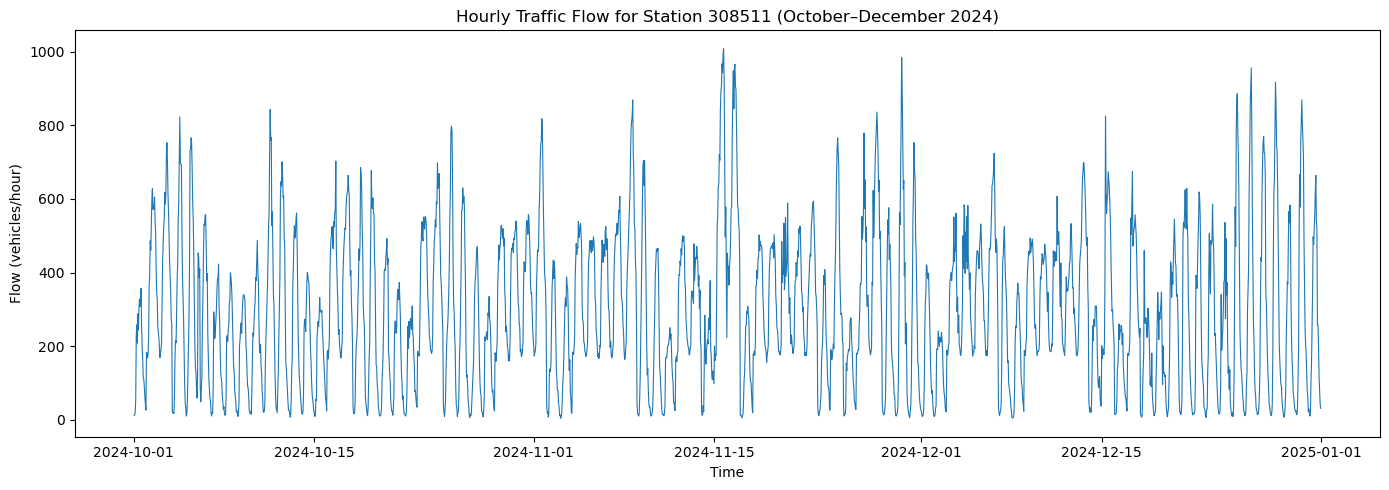

In [40]:
plt.figure(figsize=(14, 5))
plt.plot(df_station["timestamp"], df_station["flow"], linewidth=0.8)

plt.title("Hourly Traffic Flow for Station 308511 (October–December 2024)")
plt.xlabel("Time")
plt.ylabel("Flow (vehicles/hour)")

plt.tight_layout()
plt.savefig("station308511_series.png", dpi=300, bbox_inches="tight")
plt.show()